# Variant Analysis of the Hebrew Manuscripts of Ben Sira

In [1]:
import os
import copy
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score


In [ ]:
words_count = {}
variations = {}
ratio_var = {}
ratio_var_scored = {}

#All scored at 1
score = {
        "Inversion": 1,
        "Lexical": 1,
        "Morphological": 1,
        "Plus_Minus": 1
}
# score = {
#         "Inversion": 0.2,
#         "Lexical": 1,
#         "Morphological": 0.1,
#         "Plus_Minus": 1
# }

## 1. Load CSV Files

In [3]:
def load_csv_files(directory: str) -> dict[str, pd.DataFrame]:
    
    """
    Load all CSV files in a given directory and return them as a dictionary

    arg:
    directory(str) = the directory of the collation

    return:
    dataframes(dict) = A dictionnary contening the collation as dataframe
        MSS_X_Y = the two manuscripts compared --> key of the dictionary
        Dataframe columns:
            Chapter,
            Verse,
            Word = the word number in the verse,
            MS_X = word in MS_X,
            MS_Y = word in MS_Y,
            Categories = variant classifiaction of main categoies,
            Subcategories = variant classifiation of subcategories)
    """
    
    
    dataframes = {}
    # Loop through all the files in the directory
    for filename in os.listdir(directory):
        if filename.endswith(".csv"):
            filepath = os.path.join(directory, filename)
            # Load the CSV file into a pandas DataFrame
            df = pd.read_csv(filepath)
            # Add the DataFrame to the dictionary with the filename as the key
            filename = filename.split('.')[0]
            dataframes[filename] = df
    
    return dataframes

In [4]:
directory = './data'  # Path to the directory where the CSVs are stored
dataframes = load_csv_files(directory)


## 2. Create virtual MSS Bmargin

This function create a virtual manuscript for the margin of MS B.

It is a working hypothesis based on confidence into the scribe that copied the margins of MS B.

It take as presuposition that the scribe has been systematical in they collation. It means that, each time that their second copy differed from its main copy (main text), they reported the variant in the margin. We may consider that if they didn't, it is because they consider the variant as non relevant/representative.

In fact, unconsciously, it is exactly what we mentally did when we incorporate MS B in the stemma. As far as we are forced to ignore what is not in the margin as if it was similar to the main text.

In [5]:
"""
This function aims to create a virtual MS margin by
merging MS_X_Y <- MS_X_Ymg
Algo:
For each line of MS_X_Ymg:
    if 'MS_Ymg' <> empty:
        then
            values of 'MS_Bmg', 'Category', 'subcategory_1', 'subcategory_2' à l'emplacement 'Chapter', 'verse', 'word' de mg_df
            sont copié dans
            virtual_mg_df à la ligne contenant 'Chapter', 'Verse', 'Word', on remplace par les values récupérée 

"""

def iterate_on_mg(
        dataframes: dict[str, pd.DataFrame]
        ) -> dict[str, pd.DataFrame]:
    
    dataframes_virtual = copy.deepcopy(dataframes) # Crée une copy de dataframes qui contiendra les manuscrits virtuels
    print("The dataframes_virtual (pd.DataFrame) is created.")

    for filename, df in dataframes.items():
        if "mg" in filename:
            mg = filename # nom du mss comparé avec Xmg
            mg_df = df    # dataframe de la comparaitons avec Xmg
            virtual_mg = filename.replace("mg", "") # nom de la comparaison du mss sans la marge

            if virtual_mg in dataframes.keys():             # Teste si MSS_X_Y le nom existe
                virtual_mg_df = dataframes.get(virtual_mg)
            else:                                           # S'il n'existe pas converti en MSS_Y_X
                parts = virtual_mg.split("_")               
                virtual_mg = f"{parts[0]}_{parts[2]}_{parts[1]}"
                if virtual_mg in dataframes.keys():         # Teste si MSS_Y_X exite
                    virtual_mg_df = dataframes[virtual_mg] 

            dataframes_virtual = create_virtual_MSSmg(mg, mg_df, virtual_mg_df, dataframes_virtual)

    return dataframes_virtual


def create_virtual_MSSmg(
        mg: str,
        mg_df: pd.DataFrame,
        virtual_mg_df: pd.DataFrame,
        dataframes_virtual: dict[str, pd.DataFrame]
        ) -> dict[str, pd.DataFrame]:
  
    # Nettoie les noms de colonnes... ¯\_(ツ)_/¯
    mg_df.columns = mg_df.columns.str.strip()
    virtual_mg_df.columns = virtual_mg_df.columns.str.strip()    


    # Remplit les valeurs vides de Chapter, Verse par la valeur antérieure
    mg_df[['Chapter', 'Verse']] = mg_df[['Chapter', 'Verse']].ffill()
    virtual_mg_df[['Chapter', 'Verse']] = virtual_mg_df[['Chapter', 'Verse']].ffill()

    print(f"Creating {mg}_v in dataframes_virtual...")
    # Duplique la colonne 'MS_B'  dans ms_a_b_reconstructed
    virtual_mg_df['MS_Bmg_v'] = virtual_mg_df['MS_B']
    
    # Implementation de l'algorithme de reconstruction
    for idx, row in mg_df.iterrows():
        if pd.notna(row['MS_Bmg']) and str(row['MS_Bmg']).strip() != "":
            mask = (
                (virtual_mg_df['Chapter'] == row['Chapter']) &
                (virtual_mg_df['Verse'] == row['Verse']) &
                (virtual_mg_df['Word'] == row['Word'])
            )
            virtual_mg_df.loc[mask, 'MS_Bmg_v'] = row['MS_Bmg']
            virtual_mg_df.loc[mask, 'Categories'] = row['Categories']
            virtual_mg_df.loc[mask, 'Subcategories_1'] = row['Subcategories_1']
            virtual_mg_df.loc[mask, 'Subcategories_2'] = row['Subcategories_2']

    #Ajoute le dataframe virtuel au dictionnaire
    virtual_key = mg + "-v"
    dataframes_virtual[virtual_key] = virtual_mg_df
    
    #Supprime toutes les entrées MS_X_Bmg du dictionnaire (remplacés par MS_X_Bmg-v)
    dataframes_virtual = {k: v for k, v in dataframes_virtual.items() if not k.endswith("Bmg")}
    return dataframes_virtual

dataframes_virtual = {}
dataframes_virtual = iterate_on_mg(dataframes)
# Supprime les ancien Bmg
dataframes_virtual = {k: v for k, v in dataframes_virtual.items() if "mg" not in k or k.endswith("-v")}

dataframes_virtual.keys()

The dataframes_virtual (pd.DataFrame) is created.
Creating MSS_M_Bmg_v in dataframes_virtual...
Creating MSS_D_Bmg_v in dataframes_virtual...
Creating MSS_C_Bmg_v in dataframes_virtual...
Creating MSS_B_Bmg_v in dataframes_virtual...
Creating MSS_A_Bmg_v in dataframes_virtual...


/var/folders/4v/l62_h42s4rg1hyzc_kg9l0qm0000gn/T/ipykernel_17527/544274953.py:71: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Coordination' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  virtual_mg_df.loc[mask, 'Subcategories_2'] = row['Subcategories_2']


dict_keys(['MSS_C_D', 'MSS_A_D', 'MSS_A_B', 'MSS_E_F', 'MSS_A_C', 'MSS_B_F', 'MSS_B_E', 'MSS_B_D', 'MSS_B_C', 'MSS_B_11QPsa', 'MSS_M_B', 'MSS_M_Bmg-v', 'MSS_D_Bmg-v', 'MSS_C_Bmg-v', 'MSS_B_Bmg-v', 'MSS_A_Bmg-v'])

## 3. General Stastitics on Words

In [6]:
def count_words(dataframes: dict[str, pd.DataFrame]) -> None:
    """
    Count the number of words

    Arg:
    dataframes(dict) = the dataframes of the collation

    Return:
    
    """
    local_count = {}
    # Loop on each data frame in each csv
    for filename, df in dataframes.items():
        # select the name of columns "MS_" but excluding marginal notes "_mg"
        ms_columns = [col for col in df.columns if "MS_" in col and "_mg" not in col]

        local_count[filename] = {}
        local_count[filename]["words_ms_1"] = df[ms_columns[0]].notna().sum() #Number of words in col 1
        local_count[filename]["words_ms_2"] = df[ms_columns[1]].notna().sum() #Number of words in col 2
        local_count[filename]["words_alligned"] = df[df[ms_columns[0]].notna() & df[ms_columns[1]].notna()].shape[0] #number of aligned words
        local_count[filename]["Words_not_alligned"] = df[(df[ms_columns[1]].notna() & df[ms_columns[0]].isna()) | (df[ms_columns[0]].notna() & df[ms_columns[1]].isna())].shape[0] #number of words not aligned
        

        
        variants = df.groupby('Categories').size().to_dict() # Create a dictionary of the number of item in each category

        #Calculate the percentage of each category in relation to the number of aligned and non-aligned words
        for variant in variants:
            local_count[filename][variant] = variants[variant]# * 100 / (local_count[filename]["words_alligned"] + local_count[filename]["Words_not_alligned"])
        
        #Calculate the total number of Variants (outside of Same and Unclassifiable)
        local_count[filename]["n_variants"] = df[df['Categories'].notna() & ~df['Categories'].str.strip().isin(['Same', 'Unclassifiable'])].shape[0]

    display(pd.DataFrame.from_dict(local_count).round(1).T.fillna(""))
    return local_count

words_count = count_words(dataframes_virtual)

,words_ms_1,words_ms_2,words_alligned,Words_not_alligned,Inversion,Lexical,Morphological,Plus_Minus,Same,Unclassifiable,n_variants
MSS_C_D,113.0,125.0,109.0,20.0,6.0,10.0,11.0,17.0,62.0,29.0,44.0
MSS_A_D,327.0,266.0,260.0,73.0,,1.0,8.0,1.0,206.0,116.0,10.0
MSS_A_B,508.0,511.0,491.0,37.0,4.0,18.0,33.0,94.0,298.0,80.0,149.0
MSS_E_F,114.0,114.0,114.0,0.0,,,2.0,,58.0,28.0,2.0
MSS_A_C,399.0,431.0,370.0,90.0,6.0,69.0,49.0,51.0,233.0,6.0,175.0
MSS_B_F,298.0,267.0,247.0,71.0,2.0,23.0,20.0,47.0,153.0,56.0,92.0
MSS_B_E,122.0,119.0,118.0,5.0,,11.0,6.0,10.0,44.0,26.0,27.0
MSS_B_D,255.0,255.0,249.0,12.0,4.0,42.0,38.0,20.0,152.0,4.0,104.0
MSS_B_C,73.0,75.0,64.0,20.0,2.0,11.0,5.0,13.0,35.0,19.0,31.0
MSS_B_11QPsa,62.0,65.0,48.0,31.0,,23.0,7.0,26.0,13.0,10.0,56.0


## 4. Calcul de l'IC Wilson

,aligned,n_variants,rate (%),IC_low (%),IC_high (%)
pair,,,,,
MSS_E_F,60,2,3.3,0.9,11.4
MSS_A_D,216,10,4.6,2.5,8.3
MSS_D_Bmg-v,254,55,21.7,17.0,27.1
MSS_A_Bmg-v,446,138,30.9,26.8,35.4
MSS_A_B,447,149,33.3,29.1,37.8
MSS_B_F,245,92,37.6,31.7,43.8
MSS_B_E,71,27,38.0,27.6,49.7
MSS_B_D,256,104,40.6,34.8,46.7
MSS_C_D,106,44,41.5,32.6,51.0


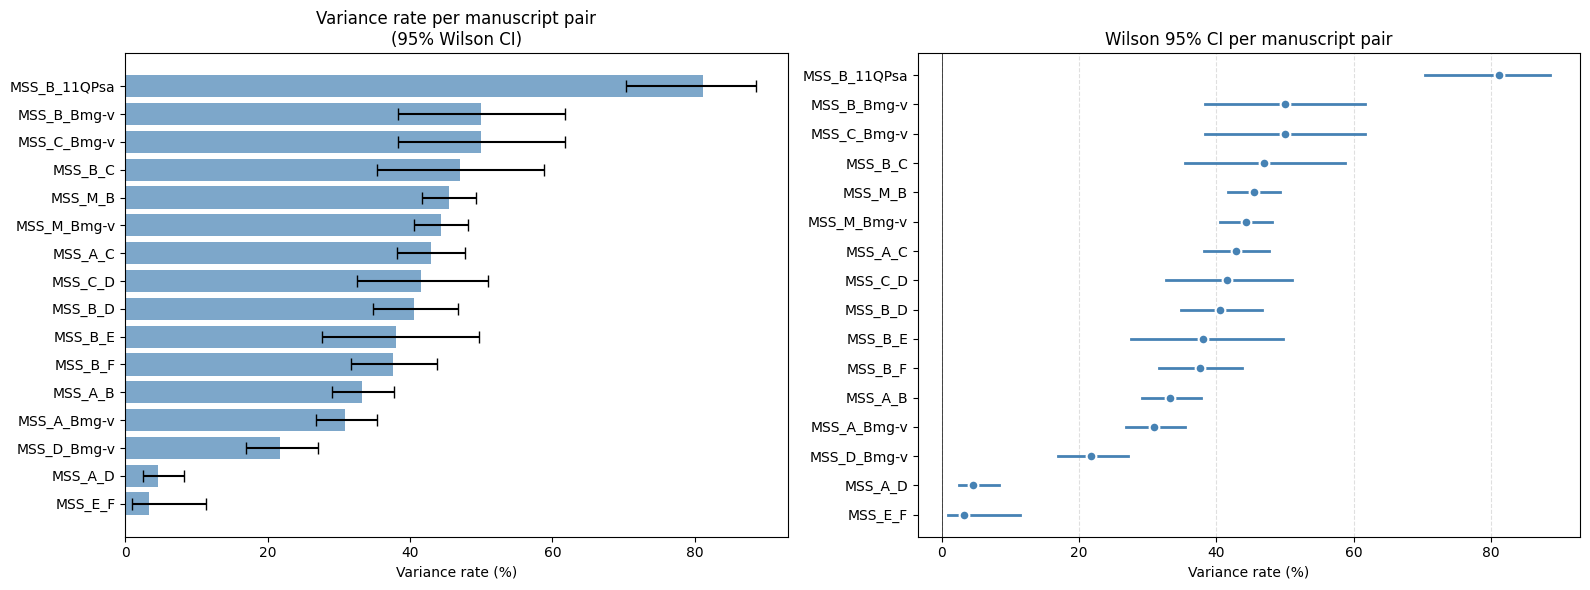

In [27]:
from scipy.stats import norm

def wilson_ci(k, n, alpha=0.05):
    if n == 0:
        return (0, 0)
    z = norm.ppf(1 - alpha / 2)
    p = k / n
    center = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    margin = z / (1 + z**2 / n) * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    return round((center - margin) * 100, 1), round((center + margin) * 100, 1)

# Appliqué sur words_count
rows = []
for filename, counts in words_count.items():
    n = counts.get("Same", 0) + counts.get("n_variants", 0)
    k = counts.get("n_variants", 0)
    lo, hi = wilson_ci(k, n)
    rows.append({
        "pair": filename,
        "aligned": n,
        "n_variants": k,
        "rate (%)": round(k * 100 / n, 1) if n > 0 else 0,
        "IC_low (%)": lo,
        "IC_high (%)": hi,
    })

df_ic = pd.DataFrame(rows).set_index("pair").sort_values("rate (%)")
display(df_ic)

df_plot = df_ic.dropna().sort_values("rate (%)")

yerr_low  = df_plot["rate (%)"] - df_plot["IC_low (%)"]
yerr_high = df_plot["IC_high (%)"] - df_plot["rate (%)"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Bar chart avec barres d'erreur
ax1.barh(df_plot.index, df_plot["rate (%)"],
         xerr=[yerr_low, yerr_high],
         capsize=4, color="steelblue", alpha=0.7, ecolor="black")
ax1.set_xlabel("Variance rate (%)")
ax1.set_title("Variance rate per manuscript pair\n(95% Wilson CI)")
ax1.axvline(0, color="black", linewidth=0.5)

# 2. Dot plot (forest plot)
for i, (pair, row) in enumerate(df_plot.iterrows()):
    ax2.plot([row["IC_low (%)"], row["IC_high (%)"]], [i, i],
             color="steelblue", linewidth=2)
    ax2.plot(row["rate (%)"], i, "o", color="steelblue", markersize=7,
             markeredgecolor="white", markeredgewidth=1.5)

ax2.set_yticks(range(len(df_plot)))
ax2.set_yticklabels(df_plot.index)
ax2.set_xlabel("Variance rate (%)")
ax2.set_title("Wilson 95% CI per manuscript pair")
ax2.axvline(0, color="black", linewidth=0.5)
ax2.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


              ratio
MSS_E_F         3.0
MSS_A_D         5.0
MSS_D_Bmg-v    22.0
MSS_A_Bmg-v    31.0
MSS_A_B        33.0
MSS_B_E        38.0
MSS_B_F        38.0
MSS_B_D        41.0
MSS_C_D        42.0
MSS_A_C        43.0
MSS_M_Bmg-v    44.0
MSS_M_B        45.0
MSS_B_C        47.0
MSS_B_Bmg-v    50.0
MSS_C_Bmg-v    50.0
MSS_B_11QPsa   81.0


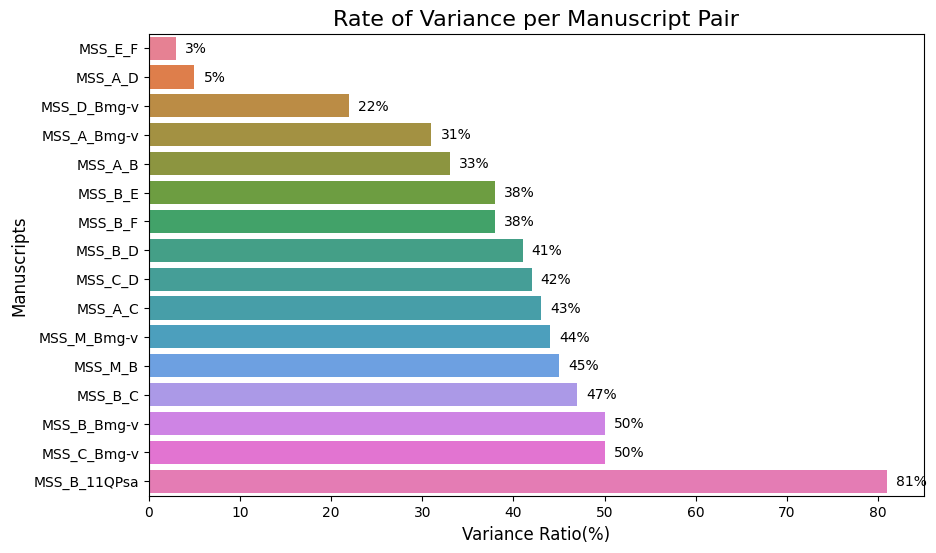

In [29]:
"""
SUPPRIMER
"""


"""
Ratio of variations
"""


def ratio_variance(dfs: dict[str, pd.DataFrame]) -> pd.DataFrame: 
    # Loop on each data frame in each csv
    #print(dfs.keys())
    variations = {}

    for filename, df in dfs.items():
        df['Categories'] = df['Categories'].str.strip()
        #Deletion of “Unclassifiable” lines
        df = df[df['Categories'] != 'Unclassifiable']
        
        variations[filename] = {}

        variants = df[df['Categories'] != 'Same'].groupby('Categories').size().sum()
        same = df[df['Categories'] == 'Same'].shape[0]
        ratio = variants * 100  / (variants+same)
        variations[filename]=[ratio]

    df = pd.DataFrame.from_dict(variations).round(0).T.sort_index(ascending=True)
    df.columns = ["ratio"]
    df = df.sort_values(by="ratio", ascending=True) #Sort by Value
    #df = df[~df.index.str.endswith('mg')] #delete all mg 
    print(df)
    # Créer le barplot horizontal
    plt.figure(figsize=(10, 6))
    #sns.set(style="whitegrid")
    palette = sns.color_palette("pastel", as_cmap=False)

    # Trace un barplot horizontal
    ax = sns.barplot(x="ratio", y=df.index, data=df, hue=df.index, dodge=False)

    # Ajouter la valeur du ratio à côté de chaque barre
    for i, (value, label) in enumerate(zip(df["ratio"], df.index)):
        ax.text(value + 1, i, f"{value:.0f}%", va='center', fontsize=10, color='black')

    # Ajouter un titre et des labels
    plt.title("Rate of Variance per Manuscript Pair without score", fontsize=16)

    # Ajouter un titre et des labels
    plt.title("Rate of Variance per Manuscript Pair", fontsize=16)
    plt.xlabel("Variance Ratio(%)", fontsize=12)
    plt.ylabel("Manuscripts", fontsize=12)

    # Afficher le graphique
    plt.show()
    #print("Index du DataFrame final :", df.index.tolist())
    return df

ratio = ratio_variance(dataframes_virtual)


# 5. Hierarchical Clustering with a variance score to 1

In [9]:
"""
SUPPRIMER ?
"""


def ratio_to_matrix(ratio: pd.DataFrame) -> pd.DataFrame:

    """
    Converti un dataFrame de ratios en matrice de distance

        arg:
        ratio(pd.DataFrame) = un dataframe contenant une distance de variance du type
                                    ratio
                    MSS_E_F              3.0
                    MSS_A_D              5.0    
                    ...

        return:
        dist_matrix(pd.DataFrame) = un dataframe contenant un matrice de distance du type
                                A     B   Bmg     C     D
                        A     0.0  31.0  31.0  43.0   5.0
                        B    31.0   0.0  50.0  50.0  22.0
                        Bmg  31.0  50.0   0.0  50.0  22.0
                        C    43.0  50.0  50.0   0.0  42.0
                        D     5.0  22.0  22.0  42.0   0.0
    """

    pairs = ratio.index.str.replace("MSS_", "").str.split("_")
    #print(f"Paires: {pairs}")
    mss_set = set()
    for p in pairs:
        mss_set.update(p[:2])
    mss = sorted(mss_set)

    # Créer la matrice vide
    dist_matrix = pd.DataFrame(np.nan, index=mss, columns=mss)

    # Remplir la matrice directement depuis le DataFrame
    for idx, row in ratio.iterrows():
        m1, m2 = idx.replace("MSS_", "").split("_")[:2]
        dist_matrix.loc[m1, m2] = row["ratio"]
        dist_matrix.loc[m2, m1] = row["ratio"]
    np.fill_diagonal(dist_matrix.values, 0)

    return dist_matrix


print(ratio)
dist_matrix = ratio_to_matrix(ratio)
print(dist_matrix)


              ratio
MSS_E_F         3.0
MSS_A_D         5.0
MSS_D_Bmg-v    22.0
MSS_A_Bmg-v    31.0
MSS_A_B        33.0
MSS_B_E        38.0
MSS_B_F        38.0
MSS_B_D        41.0
MSS_C_D        42.0
MSS_A_C        43.0
MSS_M_Bmg-v    44.0
MSS_M_B        45.0
MSS_B_C        47.0
MSS_B_Bmg-v    50.0
MSS_C_Bmg-v    50.0
MSS_B_11QPsa   81.0
        11QPsa     A     B  Bmg-v     C     D     E     F     M
11QPsa     0.0   NaN  81.0    NaN   NaN   NaN   NaN   NaN   NaN
A          NaN   0.0  33.0   31.0  43.0   5.0   NaN   NaN   NaN
B         81.0  33.0   0.0   50.0  47.0  41.0  38.0  38.0  45.0
Bmg-v      NaN  31.0  50.0    0.0  50.0  22.0   NaN   NaN  44.0
C          NaN  43.0  47.0   50.0   0.0  42.0   NaN   NaN   NaN
D          NaN   5.0  41.0   22.0  42.0   0.0   NaN   NaN   NaN
E          NaN   NaN  38.0    NaN   NaN   NaN   0.0   3.0   NaN
F          NaN   NaN  38.0    NaN   NaN   NaN   3.0   0.0   NaN
M          NaN   NaN  45.0   44.0   NaN   NaN   NaN   NaN   0.0


Pour neutraliser les valeurs manquante:
https://stackoverflow.com/questions/35611465/python-scikit-learn-clustering-with-missing-data
(with implem)
https://arxiv.org/pdf/1411.7013

## Fonctions for the Hierarchical Clustering

          A     B  Bmg-v     C     D
A       0.0  33.0   31.0  43.0   5.0
B      33.0   0.0   50.0  47.0  41.0
Bmg-v  31.0  50.0    0.0  50.0  22.0
C      43.0  47.0   50.0   0.0  42.0
D       5.0  41.0   22.0  42.0   0.0
[[ 0.          4.          5.          2.        ]
 [ 2.          5.         26.5         3.        ]
 [ 1.          6.         41.33333333  4.        ]
 [ 3.          7.         45.5         5.        ]]


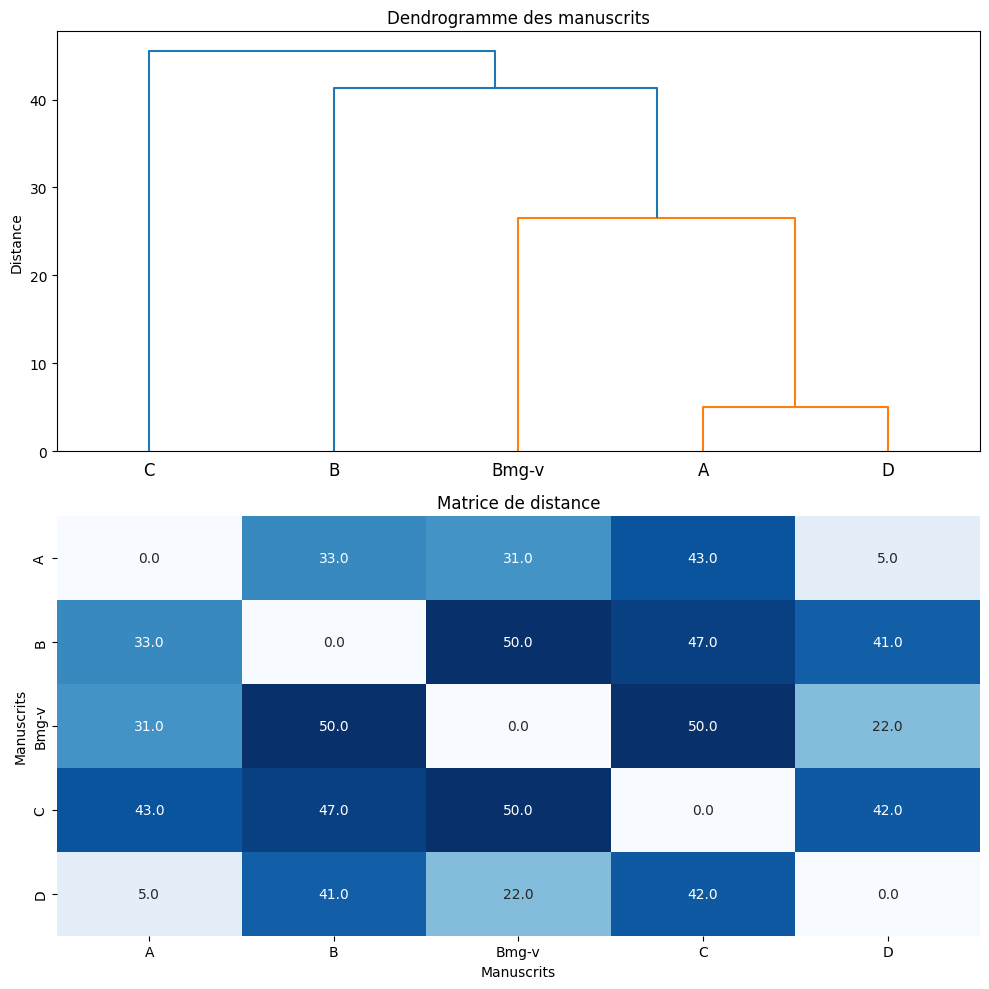

In [10]:
def get_largest_complete_submatrix(dist_matrix: pd.DataFrame) -> pd.DataFrame:
    """
    Pour chaque sous-ensemble de manuscrits, on teste si la sous-matrice est complète (pas de NaN)
    On commence par les plus grands ensembles possibles

    arg:
    dist_matrix (pd.DataFrame) = la matrice complète des distances de manuscrits avec des fragmentations
    
    return: 
    sub (pd.DataFrame) = la plus grande matrice complète possible.
    """

    from itertools import combinations
    
    mss = dist_matrix.index.tolist()
    n = len(mss)
    for size in range(n, 1, -1):
        for subset in combinations(mss, size):
            sub = dist_matrix.loc[list(subset), list(subset)]
            if not sub.isnull().values.any():
                return sub
    return None  # Si rien trouvé



def hierarchical_clustering(dist_matrix: pd.DataFrame) -> None:
    """
    Réalise une classification ascendante hierarchique sur une matrice de distance et affiche un dendograme

    arg:
    dist_matrix: pd.DataFrame = une matrice de distance...

    Retunr:
    None = le dendogramme et la matrice
    """

    sub_matrix = get_largest_complete_submatrix(dist_matrix)
    print(sub_matrix)

    # Vérification de la symétrie
    assert np.allclose(sub_matrix.values, sub_matrix.values.T), "La matrice n'est pas symétrique"

    # Dendrogramme + matrice de distance
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 2]})

    # Dendrogramme
    from scipy.spatial.distance import squareform

    # Convertit la matrice carrée en vecteur condensé
    condensed = squareform(sub_matrix.values) # transforme la matrice carrée en matrice condensée
    Z = linkage(condensed, method='average') 

    print(Z)
    dendrogram(Z, labels=sub_matrix.index, ax=ax1)
    ax1.set_title("Dendrogramme des manuscrits")
    ax1.set_xlabel("")
    ax1.set_ylabel("Distance")

    # Matrice de distance
    sns.heatmap(sub_matrix, annot=True, cmap="Blues", fmt=".1f", ax=ax2, cbar=False)
    ax2.set_title("Matrice de distance")
    ax2.set_xlabel("Manuscrits")
    ax2.set_ylabel("Manuscrits")

    plt.tight_layout()
    plt.show()


hierarchical_clustering(dist_matrix)

## 6. Variation Rates by Categories

MSS_C_D nbre de variants + same : 106 - overlap : 106
MSS_A_D nbre de variants + same : 216 - overlap : 217
MSS_A_B nbre de variants + same : 447 - overlap : 448
MSS_E_F nbre de variants + same : 60 - overlap : 88
MSS_A_C nbre de variants + same : 408 - overlap : 461
MSS_B_F nbre de variants + same : 245 - overlap : 730
MSS_B_E nbre de variants + same : 71 - overlap : 97
MSS_B_D nbre de variants + same : 256 - overlap : 268
MSS_B_C nbre de variants + same : 66 - overlap : 66
MSS_B_11QPsa nbre de variants + same : 69 - overlap : 69
MSS_M_B nbre de variants + same : 664 - overlap : 681
MSS_M_Bmg-v nbre de variants + same : 655 - overlap : 715
MSS_D_Bmg-v nbre de variants + same : 254 - overlap : 268
MSS_C_Bmg-v nbre de variants + same : 66 - overlap : 66
MSS_B_Bmg-v nbre de variants + same : 66 - overlap : 66
MSS_A_Bmg-v nbre de variants + same : 446 - overlap : 448
ratio des manuscrit avec score
               ratio
MSS_C_D        42.0
MSS_A_D         5.0
MSS_A_B        33.0
MSS_E_F    

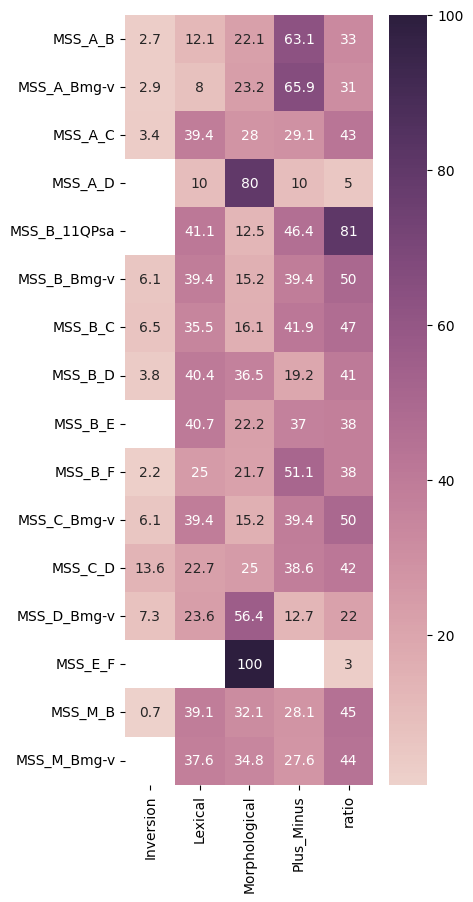

In [ ]:
"""
Variation rates on categories with score by variant:
"""

def ratio_variance_scored (dfs: dict[str, pd.DataFrame]) -> pd.DataFrame:


    for filename, df in dfs.items():

        df['Categories'] = df['Categories'].str.strip() #enlève les espaces qui pourraient trainer
        #Deletion of “Unclassifiable” lines
        df = df[df['Categories'] != 'Unclassifiable']

        ratio_var_scored[filename] = {}

        variants = df[df['Categories'] != 'Same'].groupby('Categories').size().to_dict() # Create a dictionary of the number of item in each category
        total_variants = df[df['Categories'] != 'Same'].groupby('Categories').size().sum()
        same = df[df['Categories'] == 'Same'].shape[0]
        overlap = df[df['Categories'] != 'Unclassifiable'].shape[0]
        print(f"{filename} nbre de variants + same : {total_variants + same} - overlap : {overlap}")
        scored_variants = {category: count * score.get(category, 1) for category, count in variants.items()}
        #print(f"{filename} with score : {scored_variants} - total variants {total_variants} - total mots {total_variants + same}")
        sum = 0
        for variant in variants:
            sum = sum + scored_variants[variant] * 100 / (total_variants + same)
            ratio_var_scored[filename][variant] = variants[variant] * 100 / total_variants
        ratio_var_scored[filename]["ratio"] = round(sum)
        #print(f"ratio variantes pondérées : {scored_variants}")
    table = pd.DataFrame.from_dict(ratio_var_scored).round(1).T.sort_index(ascending=True)
    plt.figure(figsize=(4, 10))
    sns.heatmap(table, annot=True, cmap=sns.cubehelix_palette(as_cmap=True), fmt='g')
    dist_df = pd.DataFrame.from_dict(ratio_var_scored).T[["ratio"]]
    return dist_df
    
ratio_scored = ratio_variance_scored(dataframes_virtual)
print(f"ratio des manuscrit avec score\n {ratio_scored}")

## 7. Variation rates by categories

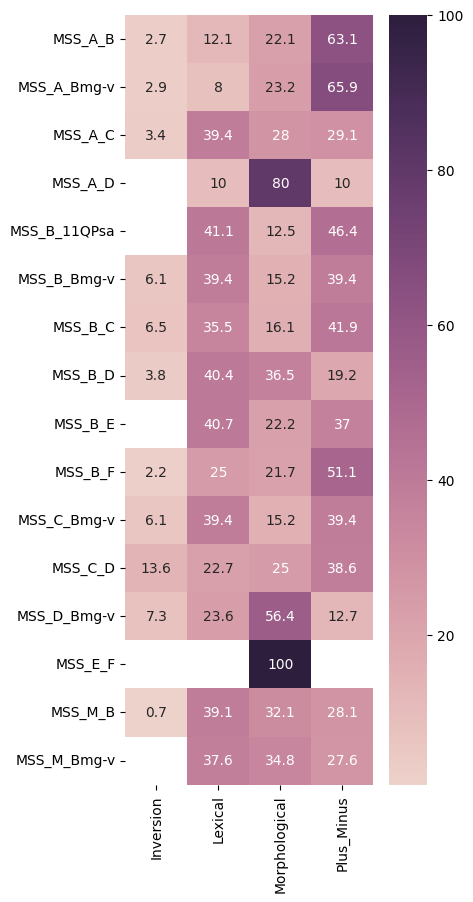

In [16]:
"""
Variation rates on categories
"""

def ratio_variance (dfs: dict[str, pd.DataFrame]) -> pd.DataFrame:

    for filename, df in dfs.items():

        #Deletion of “Unclassifiable” lines
        df = df[df['Categories'] != 'Unclassifiable']

        ratio_var[filename] = {}


        variants = df[df['Categories'] != 'Same'].groupby('Categories').size().to_dict() # Create a dictionary of the number of item in each category
        total_variants = df[df['Categories'] != 'Same'].groupby('Categories').size().sum()
        
        same = df[df['Categories'] == 'Same'].shape[0]
        #print(f"{filename} without score : {variants} - total variants {total_variants} - total mots {total_variants + same}")
        #scored_variants = {category: count * score.get(category, 1) for category, count in variants.items()}
        #print(f"{filename} with score : {scored_variants} - total variants {total_variants}")
        
        for variant in variants:
            ratio_var[filename][variant] = variants[variant] * 100 / total_variants

    table = pd.DataFrame.from_dict(ratio_var).round(1).T.sort_index(ascending=True)
    plt.figure(figsize=(4, 10))
    sns.heatmap(table, annot=True, cmap=sns.cubehelix_palette(as_cmap=True), fmt='g')

ratio_variance(dataframes_virtual)

              ratio
MSS_E_F         3.0
MSS_A_D         5.0
MSS_D_Bmg-v    22.0
MSS_A_Bmg-v    31.0
MSS_A_B        33.0
MSS_B_F        38.0
MSS_B_E        38.0
MSS_B_D        41.0
MSS_C_D        42.0
MSS_A_C        43.0
MSS_M_Bmg-v    44.0
MSS_M_B        45.0
MSS_B_C        47.0
MSS_C_Bmg-v    50.0
MSS_B_Bmg-v    50.0
MSS_B_11QPsa   81.0


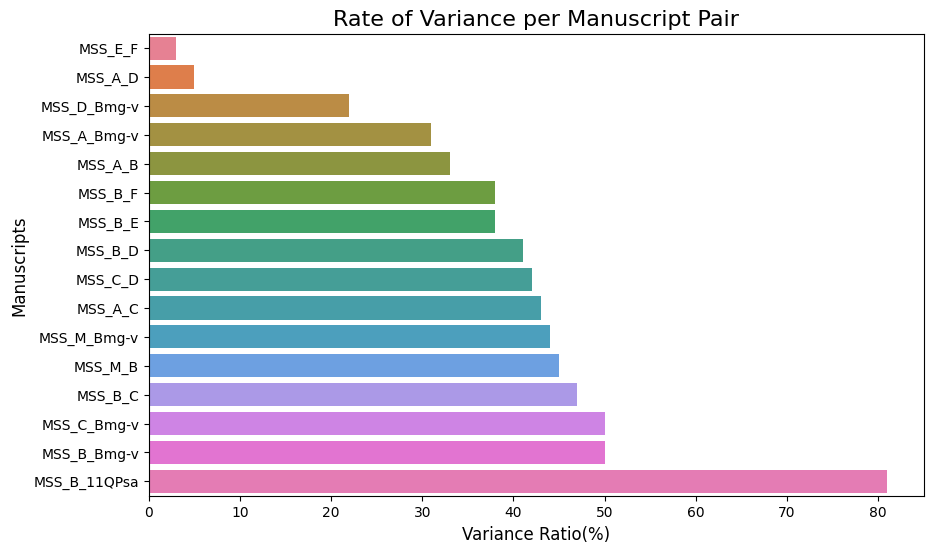

In [12]:
# Afficher Joliment les ratios

df = ratio_scored
# df.columns = ["ratio"]
df = df.sort_values(by="ratio", ascending=True) #Sort by Value
#df = df[~df.index.str.endswith('mg')] #delete all mg 
print(df)
# Créer le barplot horizontal
plt.figure(figsize=(10, 6))
#sns.set(style="whitegrid")
palette = sns.color_palette("pastel", as_cmap=False)

# Trace un barplot horizontal
sns.barplot(x="ratio", y=df.index, data=df, hue=df.index, dodge=False)

# Ajouter un titre et des labels
plt.title("Rate of Variance per Manuscript Pair", fontsize=16)
plt.xlabel("Variance Ratio(%)", fontsize=12)
plt.ylabel("Manuscripts", fontsize=12)

# Afficher le graphique
plt.show()

In [13]:
def display_matrix(matrix):
    fig, ax = plt.subplots(figsize=(10, 10), gridspec_kw={'height_ratios': [1]})
    sns.heatmap(matrix, annot=True, cmap="Blues", fmt=".1f", cbar=False)
    ax.set_title("Matrice de distance")
    ax.set_xlabel("Manuscrits")
    ax.set_ylabel("Manuscrits")
    plt.tight_layout()
    plt.show()

        11QPsa     A     B  Bmg-v     C     D     E     F     M
11QPsa     0.0   NaN  81.0    NaN   NaN   NaN   NaN   NaN   NaN
A          NaN   0.0  33.0   31.0  43.0   5.0   NaN   NaN   NaN
B         81.0  33.0   0.0   50.0  47.0  41.0  38.0  38.0  45.0
Bmg-v      NaN  31.0  50.0    0.0  50.0  22.0   NaN   NaN  44.0
C          NaN  43.0  47.0   50.0   0.0  42.0   NaN   NaN   NaN
D          NaN   5.0  41.0   22.0  42.0   0.0   NaN   NaN   NaN
E          NaN   NaN  38.0    NaN   NaN   NaN   0.0   3.0   NaN
F          NaN   NaN  38.0    NaN   NaN   NaN   3.0   0.0   NaN
M          NaN   NaN  45.0   44.0   NaN   NaN   NaN   NaN   0.0


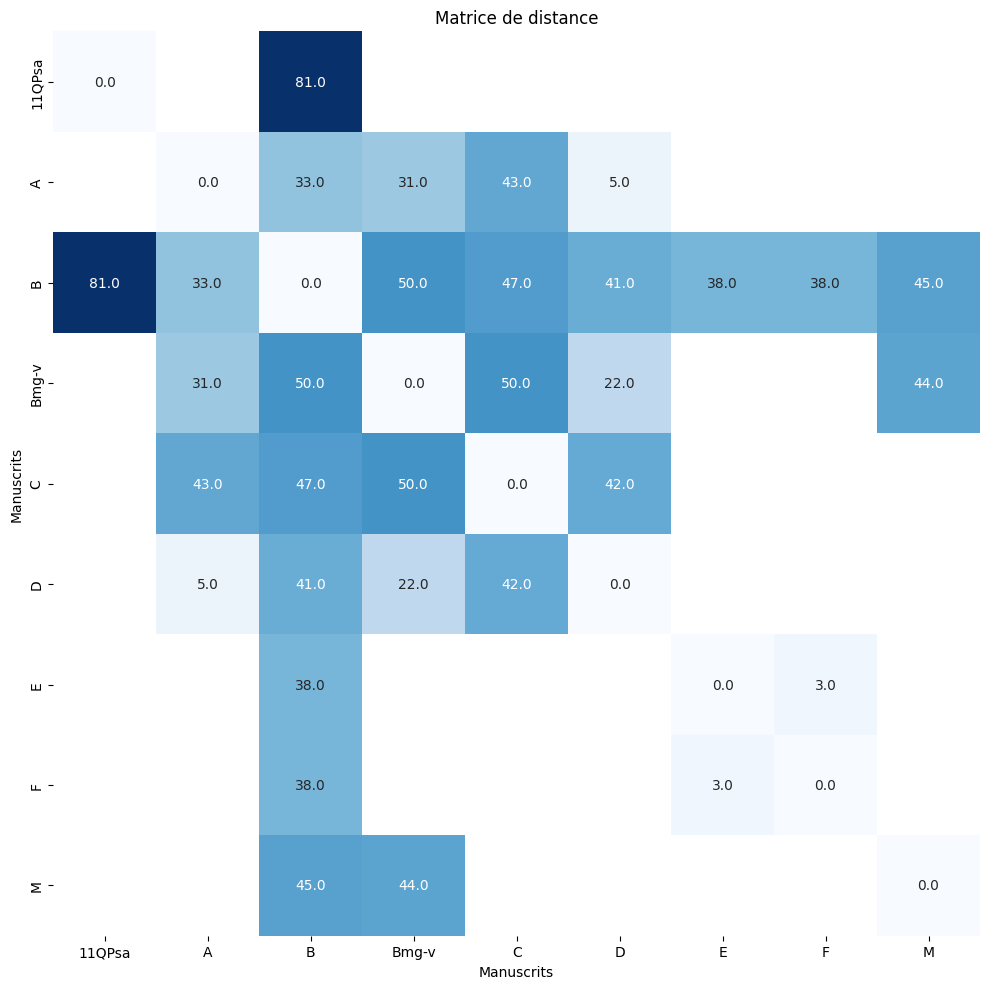

          A     B  Bmg-v     C     D
A       0.0  33.0   31.0  43.0   5.0
B      33.0   0.0   50.0  47.0  41.0
Bmg-v  31.0  50.0    0.0  50.0  22.0
C      43.0  47.0   50.0   0.0  42.0
D       5.0  41.0   22.0  42.0   0.0
[[ 0.          4.          5.          2.        ]
 [ 2.          5.         26.5         3.        ]
 [ 1.          6.         41.33333333  4.        ]
 [ 3.          7.         45.5         5.        ]]


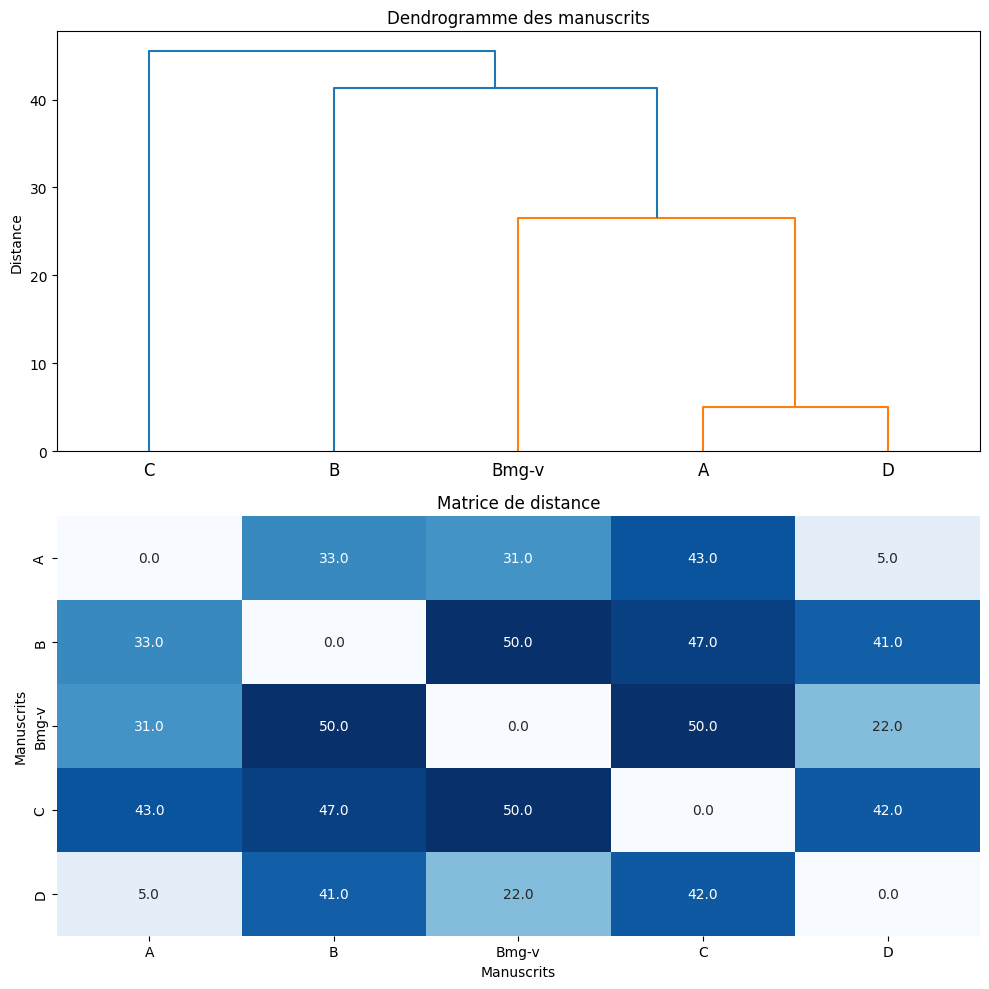

In [14]:
dist_matrix_scored = ratio_to_matrix(ratio_scored)
print(f"{dist_matrix_scored}")
display_matrix(dist_matrix_scored)
hierarchical_clustering(dist_matrix_scored)

# 7. Variation by categories with score + silhouette clustering

k=2 : silhouette score = 0.272
k=3 : silhouette score = 0.319
k=4 : silhouette score = 0.322

Nombre optimal de clusters : 4
Score de silhouette optimal : 0.322


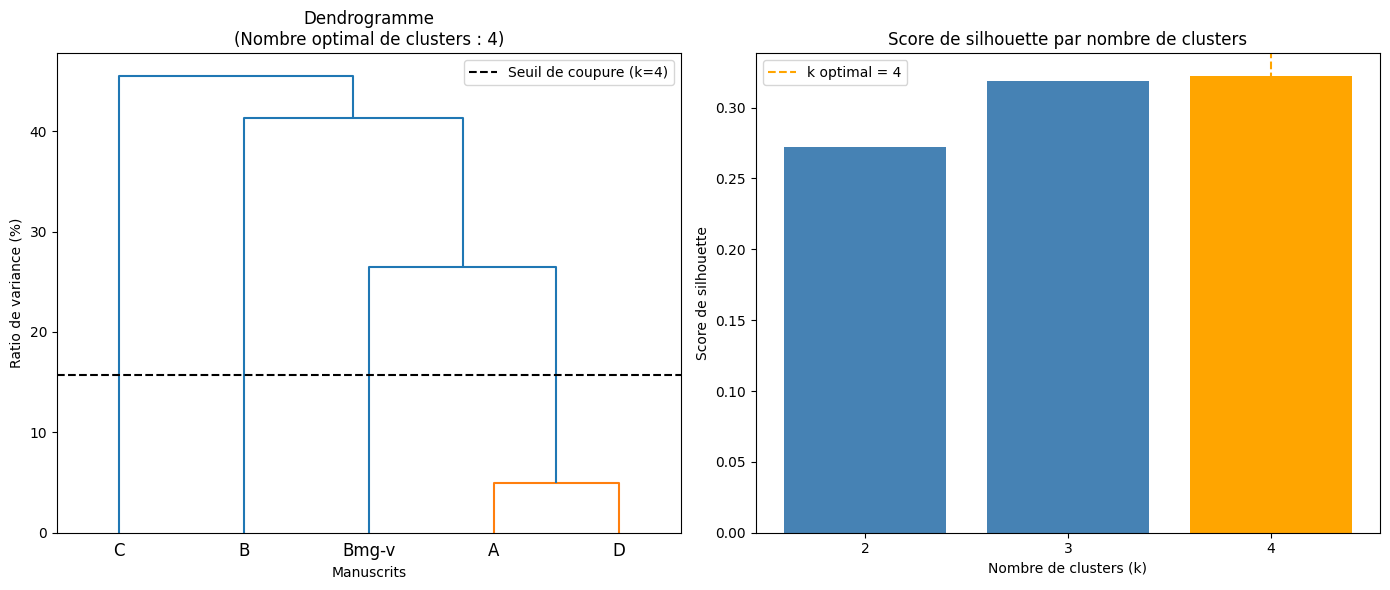

In [15]:
def compute_silhouette_and_plot(dist_matrix: pd.DataFrame):
    """
    Calcule le score de silhouette pour k=2 à k=n-1 clusters,
    détermine le k optimal, et trace le dendrogramme avec la ligne de coupure.
    """

    # 1. Préparer la matrice de distance
    sub_matrix = get_largest_complete_submatrix(dist_matrix)  
    labels = sub_matrix.index.tolist()                         
    dist_array = squareform(sub_matrix.values)                 
    Z = linkage(dist_array, method='average')

    
    # 2. Calculer le score de silhouette pour chaque k
    silhouette_scores = {}
    k_range = range(2, len(labels))  # de 2 à n-1 clusters
    
    for k in k_range:
        cluster_labels = fcluster(Z, k, criterion='maxclust')
        score = silhouette_score(
            sub_matrix.values, 
            cluster_labels, 
            metric='precomputed'
        )
        silhouette_scores[k] = score
        print(f"k={k} : silhouette score = {score:.3f}")
    
    # 3. Trouver le k optimal
    k_optimal = max(silhouette_scores, key=silhouette_scores.get)
    print(f"\nNombre optimal de clusters : {k_optimal}")
    print(f"Score de silhouette optimal : {silhouette_scores[k_optimal]:.3f}")
    
    # 4. Calculer le seuil de coupure pour le k optimal
    cluster_labels_optimal = fcluster(Z, k_optimal, criterion='maxclust')
    
    # Le seuil est la moyenne entre la dernière fusion incluse
    # et la première fusion exclue dans le dendrogramme
    distances = Z[:, 2]  # distances de fusion dans l'ordre
    n = len(labels)
    # La coupure pour k clusters se situe entre la (n-k)ème 
    # et la (n-k+1)ème fusion
    cut_threshold = (distances[n - k_optimal] + distances[n - k_optimal - 1]) / 2
    
    # 5. Tracer le dendrogramme avec la ligne de coupure
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # -- Dendrogramme --
    ax1 = axes[0]
    plt.sca(ax1)
    dendrogram(
        Z,
        labels=labels,
        ax=ax1,
        color_threshold=cut_threshold
    )
    ax1.axhline(
        y=cut_threshold, 
        color='black', 
        linestyle='--', 
        linewidth=1.5,
        label=f'Seuil de coupure (k={k_optimal})'
    )
    ax1.set_title(
        f'Dendrogramme\n(Nombre optimal de clusters : {k_optimal})',
        fontsize=12
    )
    ax1.set_xlabel('Manuscrits')
    ax1.set_ylabel('Ratio de variance (%)')
    ax1.legend()
    
    # -- Scores de silhouette --
    ax2 = axes[1]
    ax2.bar(
        list(silhouette_scores.keys()), 
        list(silhouette_scores.values()),
        color=['orange' if k == k_optimal else 'steelblue' 
               for k in silhouette_scores.keys()]
    )
    ax2.set_xlabel('Nombre de clusters (k)')
    ax2.set_ylabel('Score de silhouette')
    ax2.set_title('Score de silhouette par nombre de clusters')
    ax2.set_xticks(list(k_range))
    ax2.axvline(
        x=k_optimal, 
        color='orange', 
        linestyle='--',
        label=f'k optimal = {k_optimal}'
    )
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig('dendrogramme_silhouette.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return k_optimal, silhouette_scores

# Appel de la fonction sur ta sous-matrice
k_optimal, scores = compute_silhouette_and_plot(dist_matrix_scored)

## Variation rates by subcategories

<Axes: >

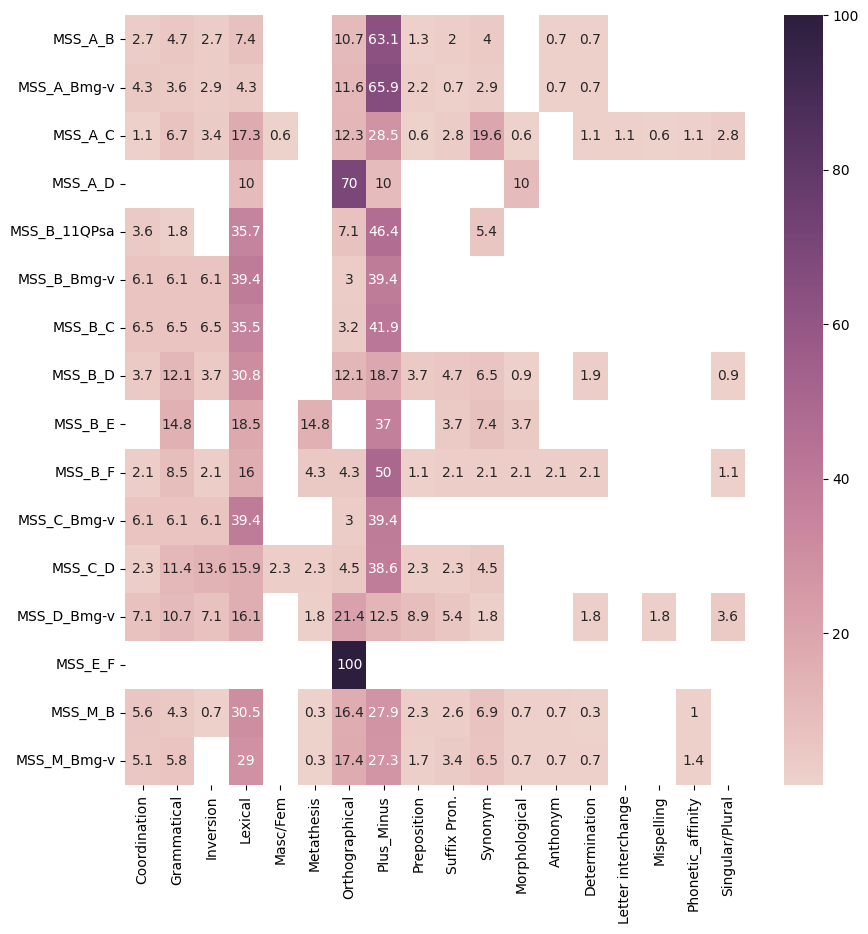

In [17]:
"""
Variation rates by subcategories
"""

ratio_var = {}
for filename, df in dataframes_virtual.items():

    

    #Deletion of “Unclassifiable” lines
    df = df[df['Categories'] != 'Unclassifiable']

    #merge categories and subcategories
    df.loc[:, 'Subcategories_1'] = df['Subcategories_1'].fillna(df['Categories'])

    #Delete "same" lines
    df = df[df['Subcategories_1'] != 'Same']
 
    ratio_var[filename] = {}
    
    variants1 = df.groupby('Subcategories_1').size() # Create a dataframe of the number of item in each subcategories_1
    variants2 = df.groupby('Subcategories_2').size() # Create a dataframe of the number of item in each subcategories_2

# Fusionner les deux DataFrames sur la colonne 'Subcategories_1'  
    variants1 = variants1.reset_index()
    variants1.columns=["Subcategories", "value"]
    variants2 = variants2.reset_index()
    variants2.columns=["Subcategories", "value"]
    merged_variants = pd.merge(variants1, variants2, on='Subcategories', how='outer')
    merged_variants['Total'] = merged_variants['value_x'].fillna(0) + merged_variants['value_y'].fillna(0)
    variants = merged_variants.set_index('Subcategories')['Total'].to_dict()

    
    total_variants = merged_variants['Total'].sum()
    
    for variant in variants:
        ratio_var[filename][variant] = variants[variant] * 100 / total_variants
        

#pd.set_option('display.float_format', lambda x: 'd' % x)
table = pd.DataFrame.from_dict(ratio_var).round(1).T.sort_index(ascending=True)
plt.figure(figsize=(10, 10))
sns.heatmap(table, annot=True, cmap=sns.cubehelix_palette(as_cmap=True), fmt='g')
    

# Collatex allignment of Sir 37:1 (MSS B, Bmg, C and D)

+-----+----+------+------+------+-------+
| B   | כל | -    | אומר | אמר  | אהבתי |
| Bmg | כל | אוהב | אומר | -    | אהבתי |
| C   | כל | אוהב | -    | יאמר | אהבתו |
| D   | כל | אוהב | אומר | -    | אהבתי |
+-----+----+------+------+------+-------+


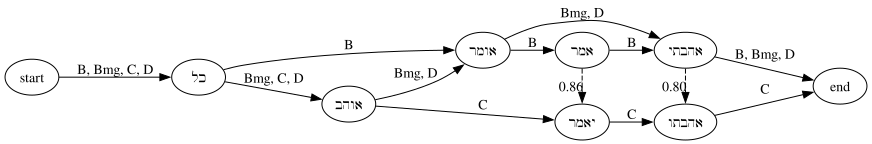

In [18]:
from collatex import *

dataset = {
    37: {
        1: {
            "B": "כל אומר אמר אהבתי",
            "Bmg":"כל אוהב אומר אהבתי",
            "C":"כל אוהב יאמר אהבתו",
            "D":"כל אוהב אומר אהבתי"
        }
    }
}

collation = Collation()
for mss in dataset[37][1].items():
    collation.add_plain_witness(mss[0], mss[1])

alligment_table = collate(collation, near_match=True, segmentation=False)
print(alligment_table)
alligment_table_svg = collate(collation, near_match=True, segmentation=False, output = "svg_simple")

# DictaBert - Morphological Analysis of Sir 37:1

In [19]:
from transformers import AutoModel, AutoTokenizer
import json

tokenizer = AutoTokenizer.from_pretrained('dicta-il/dictabert-morph')
model = AutoModel.from_pretrained('dicta-il/dictabert-morph', trust_remote_code=True)
model.eval()
for mss in dataset[37][1].items():
    morph = model.predict([mss[1]], tokenizer)
    morph = json.dumps(morph, indent=2, ensure_ascii=False)
    print(f"Morphological Analysis of {mss[0]} : {morph}")

Morphological Analysis of B : [
  {
    "text": "כל אומר אמר אהבתי",
    "tokens": [
      {
        "token": "כל",
        "pos": "DET",
        "feats": {},
        "prefixes": [],
        "suffix": false
      },
      {
        "token": "אומר",
        "pos": "VERB",
        "feats": {
          "Gender": "Masc",
          "Number": "Sing",
          "Person": "1,2,3"
        },
        "prefixes": [],
        "suffix": false
      },
      {
        "token": "אמר",
        "pos": "VERB",
        "feats": {
          "Gender": "Masc",
          "Number": "Sing",
          "Person": "3",
          "Tense": "Past"
        },
        "prefixes": [],
        "suffix": false
      },
      {
        "token": "אהבתי",
        "pos": "NOUN",
        "feats": {
          "Gender": "Fem",
          "Number": "Sing"
        },
        "prefixes": [],
        "suffix": "ADP_PRON",
        "suffix_feats": {
          "Gender": "Fem,Masc",
          "Number": "Sing",
          "Person": "1"
   

In [20]:

def show_variants(pair_key: str, dfs: dict = dataframes_virtual) -> pd.DataFrame:
    df = dfs[pair_key].copy()
    df.columns = df.columns.str.strip()

    # Extrait les deux noms de manuscrits depuis la clé (ex: "MSS_A_C" → MS_A, MS_C)
    key_body = pair_key.replace("MSS_", "")
    first_sep = key_body.index("_")
    ms1 = "MS_" + key_body[:first_sep]
    ms2 = "MS_" + key_body[first_sep + 1:].replace("-", "_")

    parallels = df[
        df[ms1].notna() &
        df[ms2].notna() &
        ~df["Categories"].isin(["Same", "Unclassifiable"])
    ].copy()

    sort_cols = [c for c in ["Categories", "Subcategories_1", "Chapter", "Verse"] if c in df.columns]
    parallels = parallels.sort_values(sort_cols)

    cols = ["Chapter", "Verse", "Word", ms1, ms2, "Categories", "Subcategories_1", "Subcategories_2"]
    cols = [c for c in cols if c in df.columns]

    with pd.option_context('display.max_rows', None):
        display(parallels[cols])
    print(f"\nNombre de variantes : {len(parallels)}")
    #return parallels

show_variants("MSS_C_D")


,Chapter,Verse,Word,MS_C,MS_D,Categories,Subcategories_1,Subcategories_2
47,NaN,NaN,6.0,גבר,נבון,Inversion,NaN,NaN
48,NaN,NaN,7.0,נבון,גבר,Inversion,NaN,NaN
80,NaN,NaN,NaN,בצבא,בגדוד,Inversion,NaN,NaN
81,NaN,NaN,NaN,גדוד,צבא,Inversion,NaN,NaN
71,NaN,NaN,NaN,גדר,דגר,Lexical,Metathesis,NaN
11,NaN,NaN,3.0,אהוב,חבב,Lexical,Synonym,NaN
40,NaN,NaN,7.0,להם,אליהם,Lexical,Synonym,NaN
49,NaN,NaN,8.0,זבדה,חברה,Lexical,NaN,NaN
96,NaN,NaN,NaN,בעת,דין,Lexical,NaN,NaN
98,NaN,NaN,NaN,עליו,עד,Lexical,NaN,NaN



Nombre de variantes : 25


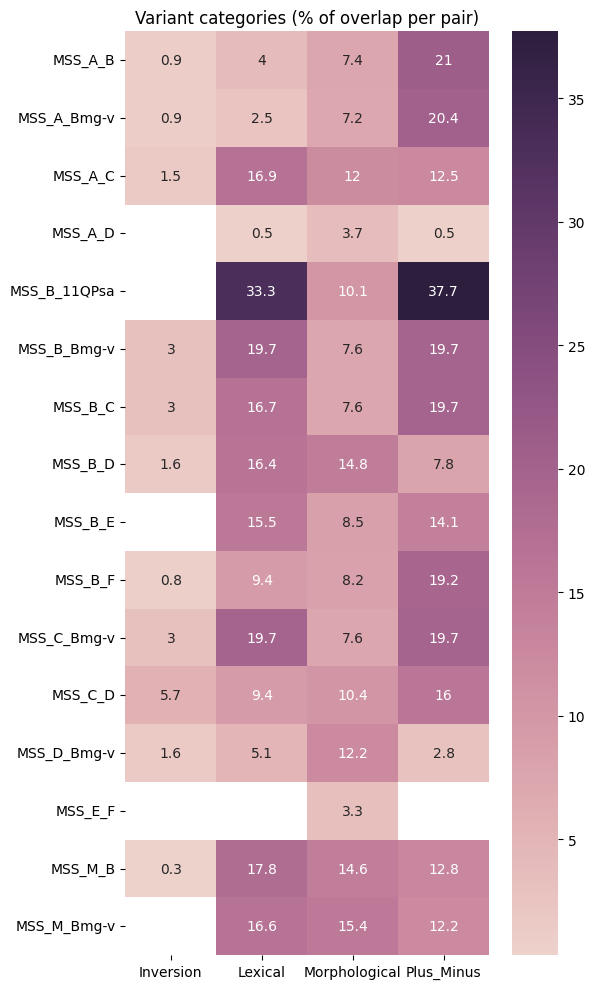

,Inversion,Lexical,Morphological,Plus_Minus,overlap
MSS_E_F,NaN,NaN,3.3,NaN,60.0
MSS_B_Bmg-v,3.0,19.7,7.6,19.7,66.0
MSS_B_C,3.0,16.7,7.6,19.7,66.0
MSS_C_Bmg-v,3.0,19.7,7.6,19.7,66.0
MSS_B_11QPsa,NaN,33.3,10.1,37.7,69.0
MSS_B_E,NaN,15.5,8.5,14.1,71.0
MSS_C_D,5.7,9.4,10.4,16.0,106.0
MSS_A_D,NaN,0.5,3.7,0.5,216.0
MSS_B_F,0.8,9.4,8.2,19.2,245.0
MSS_D_Bmg-v,1.6,5.1,12.2,2.8,254.0


In [21]:
results = {}

for filename, df in dataframes_virtual.items():
    df = df[df['Categories'] != 'Unclassifiable']
    
    variants = df[df['Categories'] != 'Same'].groupby('Categories').size()
    overlap = variants.sum() + df[df['Categories'] == 'Same'].shape[0]
    
    results[filename] = {cat: count * 100 / overlap for cat, count in variants.items()}
    results[filename]['overlap'] = overlap

table = pd.DataFrame.from_dict(results).round(1).T.sort_index()

# Heatmap sans la colonne overlap
cols = [c for c in table.columns if c != 'overlap']
plt.figure(figsize=(6, 10))
sns.heatmap(table[cols], annot=True, cmap=sns.cubehelix_palette(as_cmap=True), fmt='g')
plt.title("Variant categories (% of overlap per pair)")
plt.tight_layout()
plt.show()

display(table.sort_values('overlap'))

In [22]:
dataframes_virtual.keys()

dict_keys(['MSS_C_D', 'MSS_A_D', 'MSS_A_B', 'MSS_E_F', 'MSS_A_C', 'MSS_B_F', 'MSS_B_E', 'MSS_B_D', 'MSS_B_C', 'MSS_B_11QPsa', 'MSS_M_B', 'MSS_M_Bmg-v', 'MSS_D_Bmg-v', 'MSS_C_Bmg-v', 'MSS_B_Bmg-v', 'MSS_A_Bmg-v'])

In [23]:
df = dataframes_virtual['MSS_B_E']
df = df[df['Categories'] != 'Unclassifiable']
df = df[df['Categories'] != 'Same']
print(df['Subcategories_1'].value_counts(dropna=False))

Subcategories_1
NaN             42
Metathesis       4
Grammatical      4
Synonym          2
Suffix Pron.     1
Name: count, dtype: int64
